# Análise dos resultados do enem-llm-benchmark

Neste notebook eu analiso como modelos de linguagem gratuitos se saíram nas questões do ENEM 2025, partindo dos CSV que o benchmark gera. A pergunta que me guia é direta, quão bem esses modelos respondem à prova, em que áreas eles erram mais, e o quanto a parte visual das questões com figura derruba o desempenho. Como as amostras por área são modestas, eu reporto cada taxa com intervalo de confiança, para separar diferença real de ruído.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

ordem_areas = ["linguagens", "humanas", "natureza", "matematica"]
rotulos = {
    "linguagens": "Linguagens",
    "humanas": "Ciências Humanas",
    "natureza": "Ciências da Natureza",
    "matematica": "Matemática",
}


def intervalo_wilson(acertos, total, z=1.96):
    """Intervalo de confiança de Wilson para a acurácia, em fração de 0 a 1."""
    if total == 0:
        return (0.0, 0.0)
    p = acertos / total
    denominador = 1 + z**2 / total
    centro = (p + z**2 / (2 * total)) / denominador
    margem = z * (p * (1 - p) / total + z**2 / (4 * total**2)) ** 0.5 / denominador
    return (max(0.0, centro - margem), min(1.0, centro + margem))


df = pd.read_csv("../results/resultados.csv")
print(f"{len(df)} respostas de {df['modelo'].nunique()} modelos")
print(f"{df['questao_id'].nunique()} questões distintas avaliadas")
df.head()

580 respostas de 5 modelos
116 questões distintas avaliadas


,questao_id,modelo,ano,area,tem_imagem,alternativa,gabarito,acertou
0,enem-2025-01,groq-llama-8b,2025,linguagens,0,D,D,1
1,enem-2025-02,groq-llama-8b,2025,linguagens,0,D,D,1
2,enem-2025-03,groq-llama-8b,2025,linguagens,0,D,D,1
3,enem-2025-04,groq-llama-8b,2025,linguagens,0,E,E,1
4,enem-2025-06,groq-llama-8b,2025,linguagens,0,A,E,0


## O conjunto avaliado

Antes de olhar a acurácia, vale dimensionar o que estou medindo, porque amostras pequenas pedem cautela na hora de concluir. A contagem abaixo mostra quantas questões distintas há em cada área neste recorte, que é só de questões de texto, já que os modelos puramente textuais não enxergam imagem.

In [2]:
questoes = df.drop_duplicates("questao_id")
contagem = questoes["area"].value_counts().reindex(ordem_areas)
contagem.index = [rotulos[a] for a in contagem.index]
contagem.to_frame("questões de texto")

,questões de texto
Linguagens,33
Ciências Humanas,40
Ciências da Natureza,21
Matemática,22


## Acurácia por modelo, com intervalo de confiança

A acurácia é a fração de questões que o modelo acertou, comparando a letra respondida com o gabarito. Junto de cada taxa eu mostro o intervalo de 95% pelo método de Wilson, e o número de questões, para deixar claro sobre quanto a conta foi feita.

In [3]:
linhas = []
for modelo, grupo in df.groupby("modelo"):
    acertos, total = int(grupo["acertou"].sum()), len(grupo)
    baixo, alto = intervalo_wilson(acertos, total)
    linhas.append(
        {
            "modelo": modelo,
            "acurácia (%)": round(100 * acertos / total, 1),
            "IC95 baixo": round(100 * baixo, 1),
            "IC95 alto": round(100 * alto, 1),
            "questões": total,
        }
    )
por_modelo = pd.DataFrame(linhas).set_index("modelo").sort_values("acurácia (%)", ascending=False)
por_modelo

,acurácia (%),IC95 baixo,IC95 alto,questões
modelo,,,,
groq-qwen3-32b,85.3,77.8,90.6,116
groq-gpt-oss-120b,83.6,75.8,89.3,116
groq-llama-70b,82.8,74.9,88.6,116
groq-gpt-oss-20b,75.9,67.3,82.7,116
groq-llama-8b,57.8,48.7,66.4,116


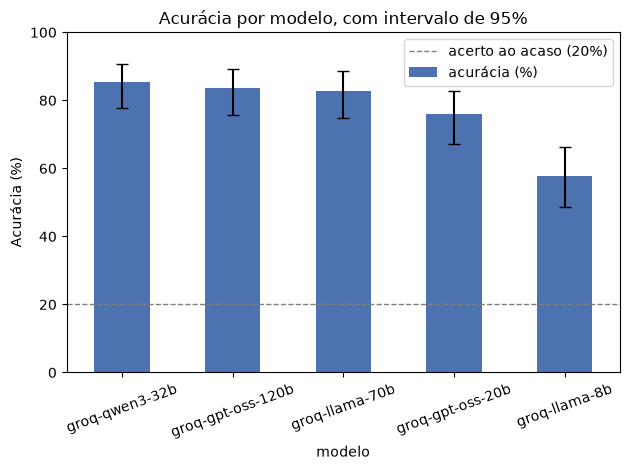

In [4]:
valores = por_modelo["acurácia (%)"]
erro = [valores - por_modelo["IC95 baixo"], por_modelo["IC95 alto"] - valores]
ax = valores.plot.bar(
    yerr=erro, capsize=4, ylim=(0, 100), ylabel="Acurácia (%)", rot=20, color="#4C72B0"
)
ax.axhline(20, linestyle="--", color="gray", linewidth=1, label="acerto ao acaso (20%)")
ax.set_title("Acurácia por modelo, com intervalo de 95%")
ax.legend()
plt.tight_layout()
plt.show()

Os intervalos contam uma história mais honesta que o ranking puro. O modelo de 8B fica claramente abaixo, mas os três do topo têm intervalos que se sobrepõem, então com essa amostra eu não consigo afirmar quem é o melhor entre eles.

## Acurácia por área

Aqui dá para ver onde a prova aperta. As ciências humanas e da natureza costumam sair na frente, e a matemática é a área mais difícil para todos os modelos, o que combina com a percepção de quem presta o ENEM.

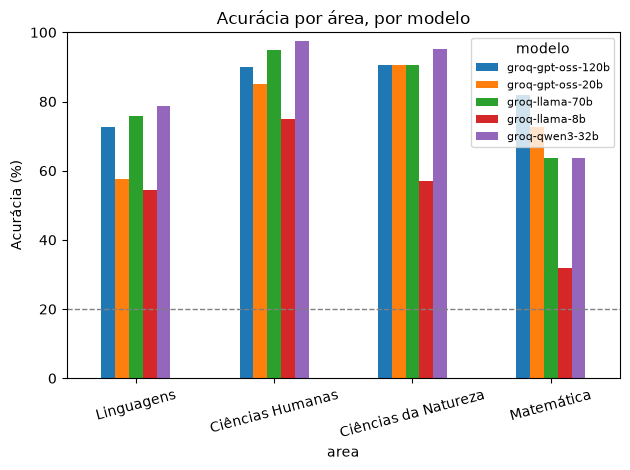

area,Linguagens,Ciências Humanas,Ciências da Natureza,Matemática
modelo,,,,
groq-gpt-oss-120b,72.7,90.0,90.5,81.8
groq-gpt-oss-20b,57.6,85.0,90.5,72.7
groq-llama-70b,75.8,95.0,90.5,63.6
groq-llama-8b,54.5,75.0,57.1,31.8
groq-qwen3-32b,78.8,97.5,95.2,63.6


In [5]:
tabela = df.pivot_table(index="modelo", columns="area", values="acertou", aggfunc="mean").mul(100)
tabela = tabela.reindex(columns=ordem_areas)
tabela_rotulada = tabela.rename(columns=rotulos)
ax = tabela_rotulada.T.plot.bar(ylim=(0, 100), ylabel="Acurácia (%)", rot=15)
ax.axhline(20, linestyle="--", color="gray", linewidth=1)
ax.set_title("Acurácia por área, por modelo")
ax.legend(title="modelo", fontsize=8)
plt.tight_layout()
plt.show()
tabela_rotulada.round(1)

## Modelo por área, o mapa de calor

O mapa de calor resume a comparação numa figura só, e é onde aparece um achado curioso. O GPT-OSS de 20 bilhões de parâmetros supera o Llama de 70 bilhões justamente em matemática, mesmo perdendo para ele nas outras áreas. Modelo maior não vence em tudo, e a área mais difícil da prova acabou premiando um modelo menor, treinado com foco em raciocínio.

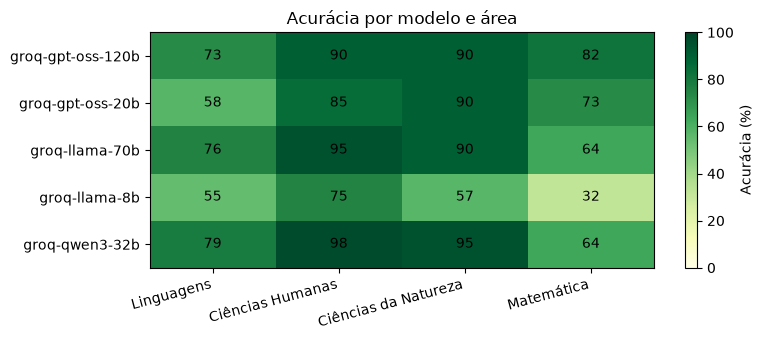

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
imagem = ax.imshow(tabela.values, cmap="YlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(ordem_areas)))
ax.set_xticklabels([rotulos[a] for a in ordem_areas], rotation=15, ha="right")
ax.set_yticks(range(len(tabela.index)))
ax.set_yticklabels(tabela.index)
for i in range(len(tabela.index)):
    for j in range(len(ordem_areas)):
        ax.text(j, i, f"{tabela.values[i][j]:.0f}", ha="center", va="center")
fig.colorbar(imagem, ax=ax, label="Acurácia (%)")
ax.set_title("Acurácia por modelo e área")
plt.tight_layout()
plt.show()

## Quem responde parecido com quem

A nota diz quem acerta mais, mas não se os modelos respondem parecido. Para isso eu monto uma rede em que cada modelo é um nó, e a ligação entre dois deles é a fração de questões em que deram a mesma alternativa, certa ou errada. No layout de força, modelos que concordam mais ficam mais próximos, e a cor do nó é a acurácia. Os quatro modelos fortes formam um bloco, e o Llama 8B, que erra mais, fica isolado, então a concordância acompanha a capacidade e não a família.

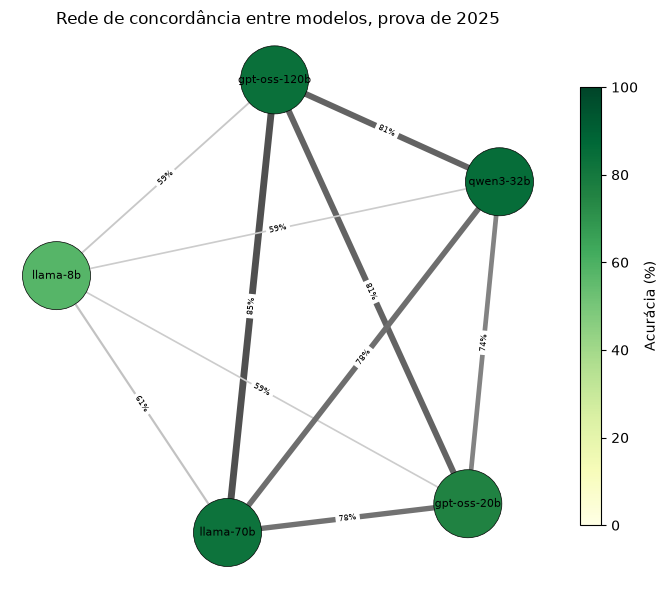

In [7]:
import networkx as nx

conc = {
    m: dict(zip(g["questao_id"], g["alternativa"], strict=True)) for m, g in df.groupby("modelo")
}
acc = df.groupby("modelo")["acertou"].mean().mul(100)

grafo = nx.Graph()
grafo.add_nodes_from(conc)
for a in sorted(conc):
    for b in sorted(conc):
        if a < b:
            comuns = set(conc[a]) & set(conc[b])
            iguais = sum(1 for q in comuns if pd.notna(conc[a][q]) and conc[a][q] == conc[b][q])
            grafo.add_edge(a, b, weight=iguais / len(comuns))

pos = nx.spring_layout(grafo, weight="weight", seed=42)
pesos = [grafo[a][b]["weight"] for a, b in grafo.edges()]
nomes = {m: m.replace("groq-", "") for m in grafo.nodes()}
rotulos = {(a, b): f"{grafo[a][b]['weight']:.0%}" for a, b in grafo.edges()}

fig, ax = plt.subplots(figsize=(7, 6))
nx.draw_networkx_edges(
    grafo,
    pos,
    width=[(p - 0.5) * 14 for p in pesos],
    edge_color=pesos,
    edge_cmap=plt.cm.Greys,
    edge_vmin=0.4,
    edge_vmax=1.0,
    ax=ax,
)
nos = nx.draw_networkx_nodes(
    grafo,
    pos,
    node_size=2400,
    node_color=[acc[m] for m in grafo.nodes()],
    cmap="YlGn",
    vmin=0,
    vmax=100,
    edgecolors="black",
    linewidths=0.5,
    ax=ax,
)
nx.draw_networkx_labels(grafo, pos, labels=nomes, font_size=8, ax=ax)
nx.draw_networkx_edge_labels(grafo, pos, edge_labels=rotulos, font_size=6, ax=ax)
fig.colorbar(nos, ax=ax, label="Acurácia (%)", shrink=0.8)
ax.set_title("Rede de concordância entre modelos, prova de 2025")
ax.axis("off")
plt.tight_layout()
plt.show()

## Texto contra imagem

Os modelos acima são só de texto, então as questões com figura ficaram de fora. Para medir o quanto a parte visual pesa, eu rodei um modelo multimodal, o Llama 4 Scout, na prova inteira, e comparo a acurácia dele nas questões de texto com a das questões que dependem de imagem.

In [8]:
img = pd.read_csv("../results/imagem_2025.csv")
linhas = []
for tem_imagem, grupo in img.groupby("tem_imagem"):
    acertos, total = int(grupo["acertou"].sum()), len(grupo)
    baixo, alto = intervalo_wilson(acertos, total)
    linhas.append(
        {
            "modalidade": "com imagem" if tem_imagem else "só texto",
            "acurácia (%)": round(100 * acertos / total, 1),
            "IC95 baixo": round(100 * baixo, 1),
            "IC95 alto": round(100 * alto, 1),
            "questões": total,
        }
    )
pd.DataFrame(linhas).set_index("modalidade")

,acurácia (%),IC95 baixo,IC95 alto,questões
modalidade,,,,
só texto,85.3,77.8,90.6,116
com imagem,59.0,46.5,70.5,61


A queda do texto para a imagem é grande, e os intervalos nem chegam a se sobrepor, então não é ruído de amostra, é um efeito real. A maior parte da dificuldade está nas figuras de matemática e ciências do segundo dia, que exigem ler gráficos e diagramas, não só reconhecer uma foto.

## O ranking se mantém ao longo dos anos

As provas de 2025 são um retrato de um ano só, então estendi a avaliação para 2022, 2023 e 2024 com o dataset aberto da Maritaca, rodando três modelos que cobrem a faixa de desempenho, o Qwen3 32B no topo, o Llama 3.3 70B no meio e o Llama 3.1 8B na base. A ordem entre eles se repete em todos os anos, sem cruzamento, o que mostra que a hierarquia é estável e o retrato de 2025 não é um acaso de uma prova específica. Montar o painel completo, com os três modelos nos três anos, exigiu coletar em mais de uma passada por causa do teto de tokens por dia do plano gratuito, que aperta nas questões de Matemática, mais longas.

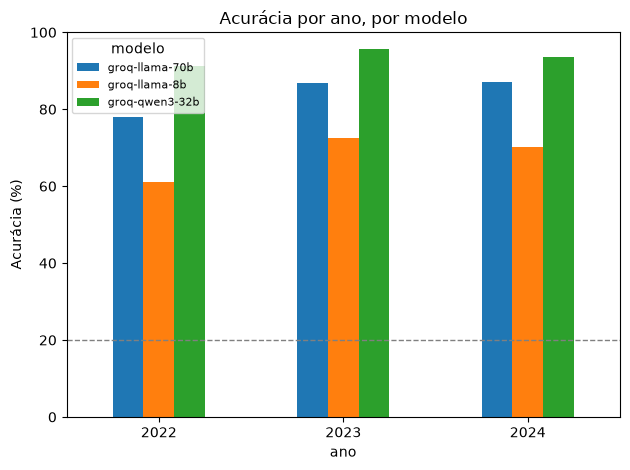

acurácia (%)  IC95 baixo  IC95 alto  questões
modelo         ano                                                
groq-llama-70b 2022          77.9        70.3       84.1       136
               2023          86.7        79.9       91.4       135
               2024          87.1        80.1       91.9       124
groq-llama-8b  2022          61.0        52.6       68.8       136
               2023          72.6        64.5       79.4       135
               2024          70.2        61.6       77.5       124
groq-qwen3-32b 2022          91.2        85.2       94.9       136
               2023          95.6        90.6       97.9       135
               2024          93.5        87.8       96.7       124

In [9]:
multi = pd.read_csv("../results/multi_ano.csv")
linhas = []
for (modelo, ano), grupo in multi.groupby(["modelo", "ano"]):
    acertos, total = int(grupo["acertou"].sum()), len(grupo)
    baixo, alto = intervalo_wilson(acertos, total)
    linhas.append(
        {
            "modelo": modelo,
            "ano": ano,
            "acurácia (%)": round(100 * acertos / total, 1),
            "IC95 baixo": round(100 * baixo, 1),
            "IC95 alto": round(100 * alto, 1),
            "questões": total,
        }
    )
por_ano = pd.DataFrame(linhas)
tabela_ano = por_ano.pivot(index="ano", columns="modelo", values="acurácia (%)")
ax = tabela_ano.plot.bar(ylim=(0, 100), ylabel="Acurácia (%)", rot=0)
ax.axhline(20, linestyle="--", color="gray", linewidth=1)
ax.set_title("Acurácia por ano, por modelo")
ax.legend(title="modelo", fontsize=8)
plt.tight_layout()
plt.show()
por_ano.set_index(["modelo", "ano"])

## A concordância também se mantém ao longo dos anos

A mesma rede de concordância, agora ano a ano e com as posições fixas para comparar. Em 2022, 2023 e 2024 a ligação mais grossa é sempre entre os dois modelos mais fortes, o Llama 70B e o Qwen3 32B, e o Llama 8B fica sempre na ponta mais solta, o que mostra que o padrão de quem responde parecido com quem é estável.

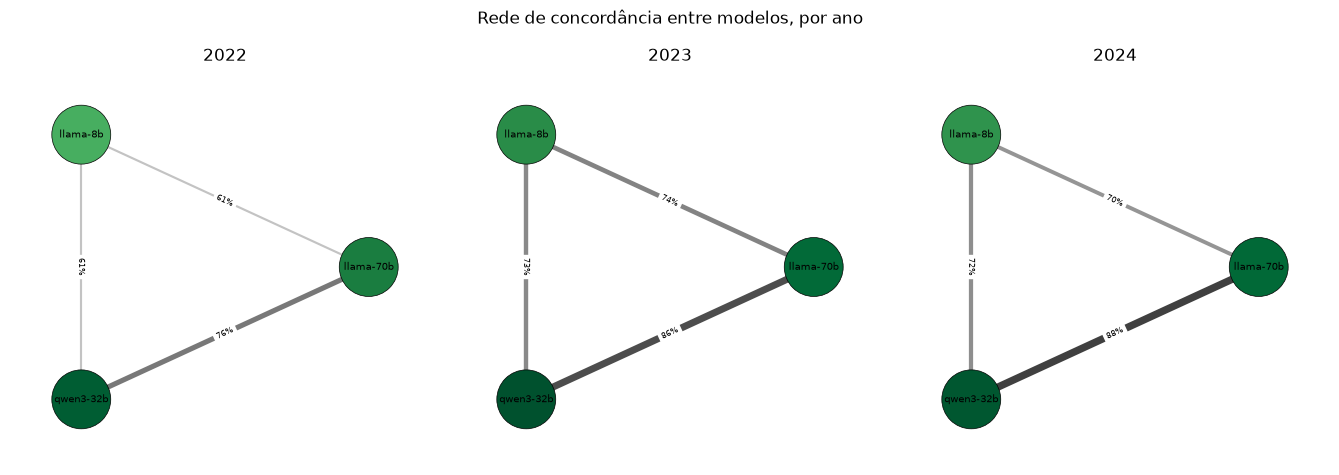

In [10]:
anos_multi = sorted(multi["ano"].unique())
modelos_multi = sorted(multi["modelo"].unique())
base = nx.Graph()
base.add_nodes_from(modelos_multi)
pos_multi = nx.circular_layout(base)
nomes_multi = {m: m.replace("groq-", "") for m in modelos_multi}

fig, eixos = plt.subplots(1, len(anos_multi), figsize=(4.5 * len(anos_multi), 4.8))
for eixo, ano in zip(eixos, anos_multi, strict=True):
    bloco = multi[multi["ano"] == ano]
    resp = {
        m: dict(zip(g["questao_id"], g["alternativa"], strict=True))
        for m, g in bloco.groupby("modelo")
    }
    acc_ano = bloco.groupby("modelo")["acertou"].mean().mul(100)
    grafo_ano = nx.Graph()
    grafo_ano.add_nodes_from(modelos_multi)
    for a in modelos_multi:
        for b in modelos_multi:
            if a < b:
                comuns = set(resp[a]) & set(resp[b])
                iguais = sum(1 for q in comuns if pd.notna(resp[a][q]) and resp[a][q] == resp[b][q])
                grafo_ano.add_edge(a, b, weight=iguais / len(comuns))
    pesos = [grafo_ano[a][b]["weight"] for a, b in grafo_ano.edges()]
    nx.draw_networkx_edges(
        grafo_ano,
        pos_multi,
        width=[(p - 0.5) * 14 for p in pesos],
        edge_color=pesos,
        edge_cmap=plt.cm.Greys,
        edge_vmin=0.4,
        edge_vmax=1.0,
        ax=eixo,
    )
    nx.draw_networkx_nodes(
        grafo_ano,
        pos_multi,
        node_size=1800,
        node_color=[acc_ano[m] for m in grafo_ano.nodes()],
        cmap="YlGn",
        vmin=0,
        vmax=100,
        edgecolors="black",
        linewidths=0.5,
        ax=eixo,
    )
    nx.draw_networkx_labels(grafo_ano, pos_multi, labels=nomes_multi, font_size=7, ax=eixo)
    rot = {(a, b): f"{grafo_ano[a][b]['weight']:.0%}" for a, b in grafo_ano.edges()}
    nx.draw_networkx_edge_labels(grafo_ano, pos_multi, edge_labels=rot, font_size=6, ax=eixo)
    eixo.set_title(str(ano))
    eixo.margins(0.18)
    eixo.axis("off")
fig.suptitle("Rede de concordância entre modelos, por ano")
plt.tight_layout()
plt.show()

## Onde os modelos erram juntos, e onde divergem

Há questões que todos os modelos erraram, e essas são candidatas a questão genuinamente difícil, ou a algum ruído na forma como extraí o texto da prova do PDF. Outras dividiram os modelos, com parte acertando e parte errando, e essas são as mais úteis para diferenciar um modelo do outro.

In [11]:
n_modelos = df["modelo"].nunique()
soma = df.groupby("questao_id")["acertou"].sum()
todos_erraram = soma[soma == 0]
todos_acertaram = soma[soma == n_modelos]
divergiram = soma[(soma > 0) & (soma < n_modelos)]
print(f"Questões que todos erraram: {len(todos_erraram)}")
print(f"Questões que todos acertaram: {len(todos_acertaram)}")
print(f"Questões em que os modelos divergiram: {len(divergiram)}")
dificeis = questoes[questoes["questao_id"].isin(todos_erraram.index)]
dificeis["area"].map(rotulos).value_counts().to_frame("questões que todos erraram")

Questões que todos erraram: 5
Questões que todos acertaram: 59
Questões em que os modelos divergiram: 52


,questões que todos erraram
area,


## Conclusão e limitações

Resumindo, os modelos maiores e o de raciocínio lideram, com um empate estatístico no topo, e o modelo de 8B fica para trás em todas as áreas. Matemática é a área mais difícil, e as questões que dependem de imagem derrubam bastante o desempenho do modelo multimodal. A comparação entre anos, de 2022 a 2024, mostra que a ordem dos modelos se mantém, então o retrato de 2025 não é um acaso da prova daquele ano. Há limites a registrar com honestidade. As amostras por área ainda são modestas, e é para isso que servem os intervalos de confiança ao longo do notebook. A comparação principal usa só questões de texto, o recorte multimodal vem de um único modelo, e a extensão para anos anteriores exigiu várias passadas de coleta por causa do teto de tokens por dia do plano gratuito. E todo o resultado depende de como extraí a prova do PDF e de como o modelo redige a resposta, por isso vale inspecionar caso a caso os erros comentados em `docs/erros_comentados.md`.